In [1]:
# CELL 1: Installation & Downloads
import subprocess
import sys

# Install packages
print(" Installing packages...")
packages = ['tensorflow', 'pennylane', 'scikit-learn', 'seaborn', 'kagglehub', 'Pillow']
for pkg in packages:
    print(f"   Installing {pkg}...", end=" ")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                         stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("✓")

# Download dataset
print("\n Downloading dataset...")
import kagglehub
import os
DATASET_PATH = kagglehub.dataset_download("nirmalsankalana/cassava-leaf-disease-classification")
print(f" Dataset downloaded at: {DATASET_PATH}")
print("\n  TESTING MODE: Using only 100 images per class for quick validation")

# Print full directory tree to understand structure
print("\n" + "="*70)
print(" FULL DIRECTORY STRUCTURE:")
print("="*70)
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = '│   ' * level
    print(f"{indent}├── {os.path.basename(root)}/")
    sub_indent = '│   ' * (level + 1)
    for i, d in enumerate(dirs):
        if i < 10:
            print(f"{sub_indent}├── {d}/")
    if len(dirs) > 10:
        print(f"{sub_indent}└── ... and {len(dirs)-10} more directories")
    for i, f in enumerate(files):
        if i < 5:
            print(f"{sub_indent}├── {f}")
    if len(files) > 5:
        print(f"{sub_indent}└── ... and {len(files)-5} more files")
print("="*70)

 Installing packages...
   Installing tensorflow... ✓
   Installing pennylane... ✓
   Installing scikit-learn... ✓
   Installing seaborn... ✓
   Installing kagglehub... ✓
   Installing Pillow... ✓



100%|██████████| 2.39G/2.39G [01:05<00:00, 39.4MB/s]

Extracting files...


 Dataset downloaded at: /root/.cache/kagglehub/datasets/nirmalsankalana/cassava-leaf-disease-classification/versions/2

  TESTING MODE: Using only 100 images per class for quick validation

 FULL DIRECTORY STRUCTURE:
├── 2/
│   ├── data/
│   ├── data/
│   │   ├── Cassava___brown_streak_disease/
│   │   ├── Cassava___green_mottle/
│   │   ├── Cassava___mosaic_disease/
│   │   ├── Cassava___healthy/
│   │   ├── Cassava___bacterial_blight/
│   │   ├── Cassava___brown_streak_disease/
│   │   │   ├── 607067900.jpg
│   │   │   ├── 3279881598.jpg
│   │   │   ├── 403051866.jpg
│   │   │   ├── 3252023035.jpg
│   │   │   ├── 1193197595.jpg
│   │   │   └── ... and 2184 more files
│   │   ├── Cassava___green_mottle/
│   │   │   ├── 2140295414.jpg
│   │   │   ├── 3028711047.jpg
│   │   │   ├── 2839650857.jpg
│   │   │   ├── 1974242714.jpg
│   │   │   ├── 3462014192.jpg
│   │   │   └── ... and 2381 more files
│   │   ├── Cassava___mosaic_disease/
│   │   │   ├── 941078633.jpg
│   │   │   ├── 2514350

In [2]:

# CELL 2: Imports & Configuration

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from PIL import Image
import pickle
import warnings

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

# Config
IMG_SIZE = 128
N_QUBITS = 2
MAX_IMAGES_PER_CLASS = 10
VGG_EPOCHS = 10
QUANTUM_EPOCHS = 10
QUANTUM_LAYERS = 2

DISEASE_CLASSES = {
    0: 'Bacterial Blight', 1: 'Brown Streak',
    2: 'Green Mottle', 3: 'Mosaic Disease', 4: 'Healthy'
}
FOLDER_MAP = {
    'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1,
    'Cassava___green_mottle': 2, 'Cassava___mosaic_disease': 3, 'Cassava___healthy': 4
}

print("="*70)
print(" TESTING MODE CONFIGURATION")
print("="*70)
print(f"TensorFlow: {tf.__version__}")
print(f"PennyLane: {qml.version()}")
print(f"Architecture: VGG16 + Quantum")
print(f"Images per class: {MAX_IMAGES_PER_CLASS}")
print(f"VGG16 epochs: {VGG_EPOCHS}")
print(f"Quantum epochs: {QUANTUM_EPOCHS}")
print(f"Quantum qubits: {N_QUBITS}")
print(f"Quantum layers: {QUANTUM_LAYERS}")
print("="*70)



/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


 TESTING MODE CONFIGURATION
TensorFlow: 2.19.0
PennyLane: 0.43.1
Architecture: VGG16 + Quantum
Images per class: 10
VGG16 epochs: 10
Quantum epochs: 10
Quantum qubits: 2
Quantum layers: 2


In [3]:

# CELL 3: Load Data

def load_data(data_dir, max_per_class=100):
    print(f"\n Searching for dataset in: {data_dir}")

    print("   Directory structure:")
    for root, dirs, files in os.walk(data_dir):
        level = root.replace(data_dir, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        if level < 2:
            subindent = ' ' * 2 * (level + 1)
            for file in files[:3]:
                print(f"{subindent}{file}")
            if len(files) > 3:
                print(f"{subindent}... and {len(files)-3} more files")

    possible_paths = [
        os.path.join(data_dir, 'data'),
        data_dir,
        os.path.join(data_dir, 'cassava-leaf-disease-classification'),
    ]

    data_folder = None
    for path in possible_paths:
        if os.path.exists(path):
            for folder_name in FOLDER_MAP.keys():
                if os.path.exists(os.path.join(path, folder_name)):
                    data_folder = path
                    break
        if data_folder:
            break

    if not data_folder:
        for root, dirs, _ in os.walk(data_dir):
            for folder_name in FOLDER_MAP.keys():
                if folder_name in dirs:
                    data_folder = root
                    break
            if data_folder:
                break

    if not data_folder:
        raise FileNotFoundError(f"Could not find dataset folders in {data_dir}")

    print(f"\n Loading from: {data_folder}")
    images, labels = [], []

    for folder_name, class_label in FOLDER_MAP.items():
        folder_path = os.path.join(data_folder, folder_name)
        if not os.path.exists(folder_path):
            print(f"  {DISEASE_CLASSES[class_label]:20} folder not found: {folder_name}")
            continue

        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:max_per_class]
        print(f"   {DISEASE_CLASSES[class_label]:20} {len(files)} images found", end="")
        loaded = 0
        for f in files:
            try:
                img = Image.open(os.path.join(folder_path, f)).convert('RGB')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                images.append(np.array(img) / 255.0)
                labels.append(class_label)
                loaded += 1
            except Exception as e:
                continue
        print(f" → {loaded} loaded ✓")

    if len(images) == 0:
        raise ValueError("No images loaded! Please check the dataset structure.")

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    print(f"\n Total: {len(images)} images")
    print(f"   Distribution: {np.bincount(labels)}")
    print(f"   Memory: {images.nbytes / (1024**2):.1f} MB")
    return images, labels

images, labels = load_data(DATASET_PATH, MAX_IMAGES_PER_CLASS)

X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.4, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print(f"\nSplit: Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


 Searching for dataset in: /root/.cache/kagglehub/datasets/nirmalsankalana/cassava-leaf-disease-classification/versions/2
   Directory structure:
2/
  data/
    Cassava___brown_streak_disease/
    Cassava___green_mottle/
    Cassava___mosaic_disease/
    Cassava___healthy/
    Cassava___bacterial_blight/

 Loading from: /root/.cache/kagglehub/datasets/nirmalsankalana/cassava-leaf-disease-classification/versions/2/data
   Bacterial Blight     10 images found → 10 loaded ✓
   Brown Streak         10 images found → 10 loaded ✓
   Green Mottle         10 images found → 10 loaded ✓
   Mosaic Disease       10 images found → 10 loaded ✓
   Healthy              10 images found → 10 loaded ✓

 Total: 50 images
   Distribution: [10 10 10 10 10]
   Memory: 9.4 MB

Split: Train: 30, Val: 10, Test: 10



 Displaying sample images from each class...


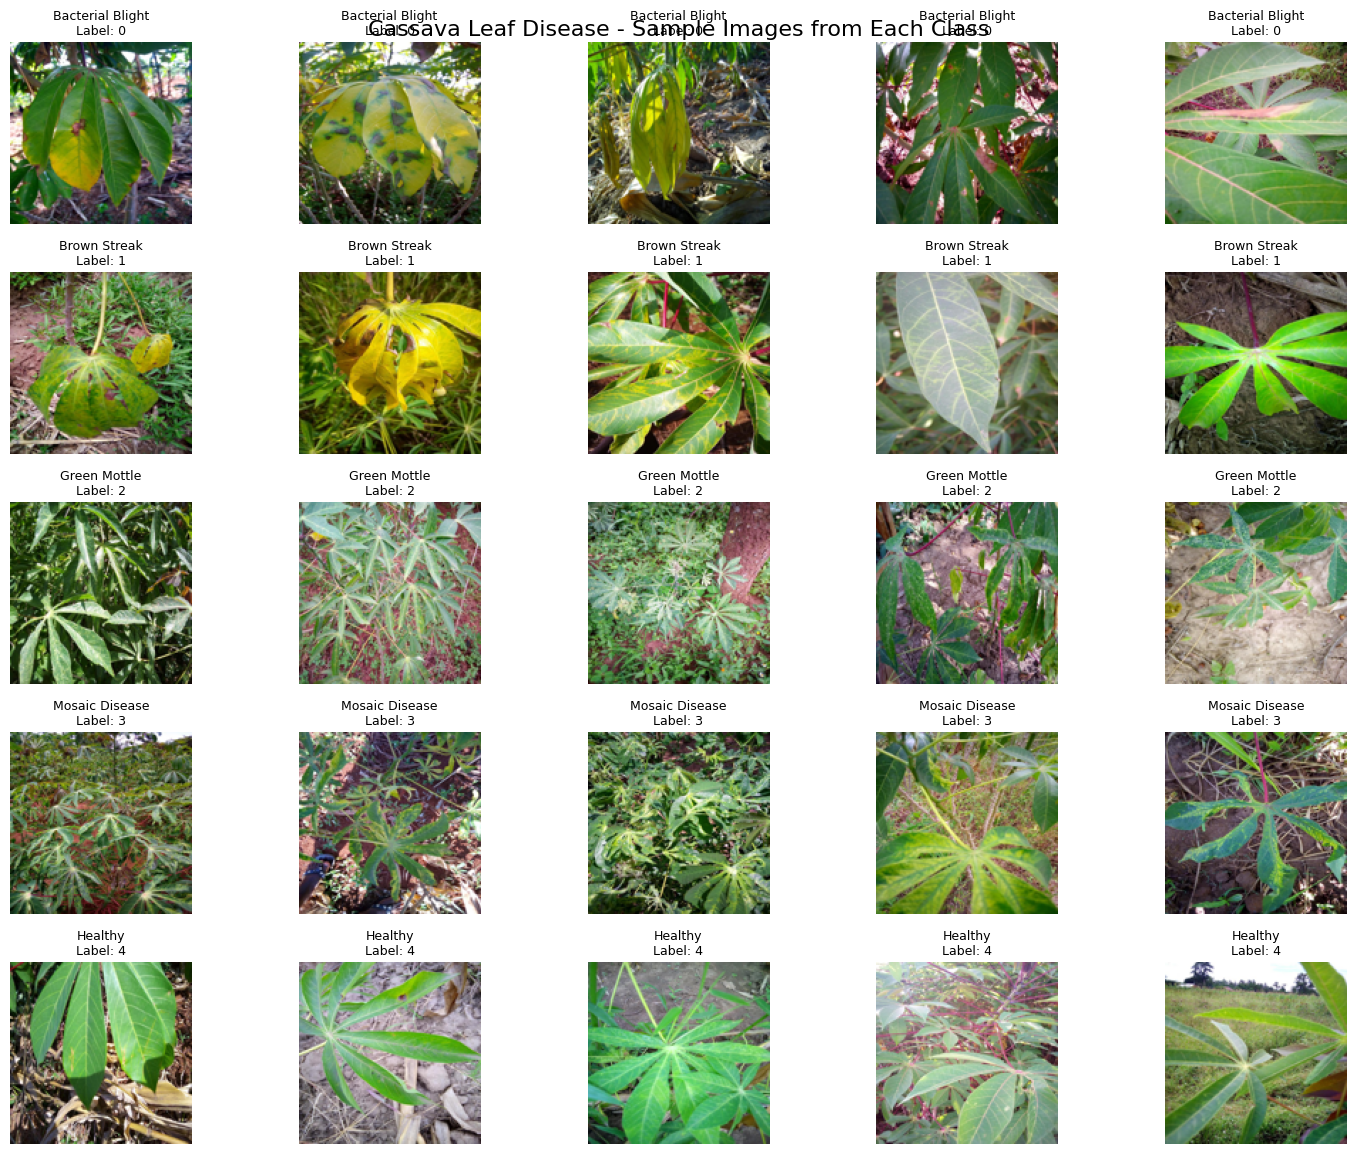


 DATASET STATISTICS
Bacterial Blight         :  10 images
Brown Streak             :  10 images
Green Mottle             :  10 images
Mosaic Disease           :  10 images
Healthy                  :  10 images
Total                    :  50 images


In [4]:

# CELL 3.5: Display Sample Images from Each Class

def display_sample_images(images, labels, num_samples=5):
    fig, axes = plt.subplots(5, num_samples, figsize=(15, 12))
    fig.suptitle('Cassava Leaf Disease - Sample Images from Each Class', fontsize=16, y=0.95)

    for class_id in range(5):
        class_name = DISEASE_CLASSES[class_id]
        class_indices = np.where(labels == class_id)[0]

        if len(class_indices) >= num_samples:
            sample_indices = class_indices[:num_samples]
        else:
            sample_indices = class_indices

        for i, idx in enumerate(sample_indices):
            if i < num_samples:
                ax = axes[class_id, i]
                ax.imshow(images[idx])
                ax.set_title(f'{class_name}\nLabel: {class_id}', fontsize=9)
                ax.axis('off')

        for i in range(len(sample_indices), num_samples):
            axes[class_id, i].axis('off')

    plt.tight_layout()
    plt.show()

    print("\n" + "="*50)
    print(" DATASET STATISTICS")
    print("="*50)
    for class_id in range(5):
        class_count = np.sum(labels == class_id)
        print(f"{DISEASE_CLASSES[class_id]:25}: {class_count:3d} images")
    print(f"{'Total':25}: {len(images):3d} images")
    print("="*50)

print("\n Displaying sample images from each class...")
display_sample_images(images, labels, num_samples=5)

In [5]:

# CELL 4: Train VGG16 Feature Extractor (Stage 1)

def build_vgg16_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)

    base_model = VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling='avg'
    )

    base_model.trainable = True
    for layer in base_model.layers[:-4]:
        layer.trainable = False

    x = base_model(x, training=True)

    features = layers.Dense(32, activation='relu', name='features')(x)
    x = layers.Dropout(0.3)(features)
    outputs = layers.Dense(5, activation='softmax')(x)

    return keras.Model(inputs, outputs)

print("\n" + "="*70)
print("STAGE 1: TRAINING VGG16 FEATURE EXTRACTOR")
print("="*70)
print(" Building and training VGG16 model...")

vgg16_model = build_vgg16_model()
vgg16_model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f" Model Parameters: {vgg16_model.count_params():,}")

history = vgg16_model.fit(
    X_train, y_train,
    batch_size=8,
    epochs=VGG_EPOCHS,
    validation_data=(X_val, y_val),
    verbose=1
)
_, vgg16_acc = vgg16_model.evaluate(X_test, y_test, verbose=0)
print(f"\n VGG16 Training Complete!")
print(f" VGG16 Test Accuracy: {vgg16_acc*100:.2f}%")

print("\n Freezing VGG16 model for feature extraction...")
for layer in vgg16_model.layers:
    layer.trainable = False
print(" VGG16 frozen - ready for quantum training")




STAGE 1: TRAINING VGG16 FEATURE EXTRACTOR
 Building and training VGG16 model...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
 Model Parameters: 14,731,269
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 922ms/step - accuracy: 0.1717 - loss: 1.9471 - val_accuracy: 0.3000 - val_loss: 1.7078
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.3042 - loss: 1.6440 - val_accuracy: 0.2000 - val_loss: 1.6669
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.3283 - loss: 1.5286 - val_accuracy: 0.3000 - val_loss: 1.6640
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3175 - loss: 1.2717 - val_accuracy: 0.2000 - val_loss: 1.9627
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5433 - loss: 1.1662 - val_accuracy: 0.3000 - val_loss: 2.0490
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5142 - loss: 0.9146 - val_accuracy: 0.2000 - val_loss: 2.7578
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3300 - loss: 1.2615

In [6]:

# CELL 5: Extract Features from Trained VGG16 (Stage 2)

print("\n" + "="*70)
print("STAGE 2: EXTRACTING FEATURES FROM TRAINED VGG16")
print("="*70)
print(" Extracting features for quantum training...")

feature_model = keras.Model(
    inputs=vgg16_model.input,
    outputs=vgg16_model.get_layer('features').output
)

print("   Extracting training features...")
features_train = feature_model.predict(X_train, batch_size=8, verbose=0)
print("   Extracting validation features...")
features_val = feature_model.predict(X_val, batch_size=8, verbose=0)
print("   Extracting test features...")
features_test = feature_model.predict(X_test, batch_size=8, verbose=0)

print(f" Feature extraction complete!")
print(f"   Train features shape: {features_train.shape}")
print(f"   Val features shape: {features_val.shape}")
print(f"   Test features shape: {features_test.shape}")

print("\n Applying PCA dimensionality reduction...")
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
features_val_scaled = scaler.transform(features_val)
features_test_scaled = scaler.transform(features_test)

pca = PCA(n_components=N_QUBITS)
pca_train = pca.fit_transform(features_train_scaled)
pca_val = pca.transform(features_val_scaled)
pca_test = pca.transform(features_test_scaled)

print(f" PCA reduction complete: {features_train.shape[1]} → {N_QUBITS} dimensions")
print(f"   Explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

def normalize_features(features):
    min_vals = features.min(axis=0)
    max_vals = features.max(axis=0)
    return (features - min_vals) / (max_vals - min_vals + 1e-8) * np.pi

angles_train = normalize_features(pca_train).astype(np.float32)
angles_val = normalize_features(pca_val).astype(np.float32)
angles_test = normalize_features(pca_test).astype(np.float32)

print(f" Features normalized to quantum angles [0, π]")
print(f"   Ready for quantum circuit training!")



STAGE 2: EXTRACTING FEATURES FROM TRAINED VGG16
 Extracting features for quantum training...
   Extracting training features...
   Extracting validation features...
   Extracting test features...
 Feature extraction complete!
   Train features shape: (30, 32)
   Val features shape: (10, 32)
   Test features shape: (10, 32)

 Applying PCA dimensionality reduction...
 PCA reduction complete: 32 → 2 dimensions
   Explained variance: 88.41%
 Features normalized to quantum angles [0, π]
   Ready for quantum circuit training!


In [7]:

# CELL 6: Train Quantum Classifier with Checkpoints (Stage 3)

print("\n" + "="*70)
print("STAGE 3: TRAINING QUANTUM CLASSIFIER (BARREN PLATEAU OPTIMIZED)")
print("="*70)
print("  Building optimized quantum circuit...")

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="tf", diff_method="parameter-shift")
def quantum_circuit(inputs, weights):
    """Data re-uploading circuit with local entanglement"""

    # Ensure inputs are float32
    inputs = tf.cast(inputs, tf.float32)
    weights = tf.cast(weights, tf.float32)

    # Layer 1: Data encoding + parameterized rotation
    for i in range(N_QUBITS):
        qml.RY(float(inputs[i]), wires=i)
    for i in range(N_QUBITS):
        qml.RY(float(weights[0, i, 0]), wires=i)
        qml.RZ(float(weights[0, i, 1]), wires=i)

    # Local entanglement (only nearest neighbors)
    for i in range(N_QUBITS-1):
        qml.CNOT(wires=[i, i+1])

    # Layer 2: Data re-uploading + parameterized rotation
    for i in range(N_QUBITS):
        # Explicit float32 casting for multiplication
        scaled_input = tf.cast(inputs[i], tf.float32) * tf.cast(weights[1, i, 0], tf.float32)
        qml.RY(float(scaled_input), wires=i)
    for i in range(N_QUBITS):
        qml.RY(float(weights[1, i, 1]), wires=i)
        qml.RZ(float(weights[1, i, 2]), wires=i)

    # Local entanglement again
    for i in range(N_QUBITS-1):
        qml.CNOT(wires=[i, i+1])

    # Local cost function: measure individual qubits (not global)
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

print(" Initializing quantum parameters (Xavier init)...")
init_scale = np.sqrt(2.0 / (N_QUBITS * QUANTUM_LAYERS))
q_weights = tf.Variable(
    tf.random.normal([QUANTUM_LAYERS, N_QUBITS, 3], 0, init_scale, dtype=tf.float32),
    name='q_weights'
)
readout_weights = tf.Variable(
    tf.random.normal([5, N_QUBITS], 0, 0.01, dtype=tf.float32),
    name='readout_weights'
)
readout_bias = tf.Variable(tf.zeros([5], dtype=tf.float32), name='readout_bias')

initial_lr = 0.0005
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=initial_lr,
    weight_decay=0.0001
)

print(f" Optimized quantum circuit ready:")
print(f"   Qubits: {N_QUBITS}")
print(f"   Layers: {QUANTUM_LAYERS}")
print(f"   Architecture: Data re-uploading with local entanglement")
print(f"   Entanglement: Nearest-neighbor only (reduced barren plateau)")
print(f"   Cost function: Local measurements (single-qubit PauliZ)")
print(f"   Total quantum parameters: {q_weights.shape[0] * q_weights.shape[1] * q_weights.shape[2]}")
print(f"   Optimizer: AdamW with LR={initial_lr}, weight_decay=0.0001")



STAGE 3: TRAINING QUANTUM CLASSIFIER (BARREN PLATEAU OPTIMIZED)
  Building optimized quantum circuit...
 Initializing quantum parameters (Xavier init)...
 Optimized quantum circuit ready:
   Qubits: 2
   Layers: 2
   Architecture: Data re-uploading with local entanglement
   Entanglement: Nearest-neighbor only (reduced barren plateau)
   Cost function: Local measurements (single-qubit PauliZ)
   Total quantum parameters: 12
   Optimizer: AdamW with LR=0.0005, weight_decay=0.0001


In [8]:

# CHECKPOINT MANAGEMENT

CHECKPOINT_DIR = 'quantum_checkpoints'
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'quantum_checkpoint.pkl')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def save_checkpoint(epoch, q_weights, readout_weights, readout_bias, optimizer,
                    best_acc, best_weights, train_losses, val_accs, train_accs,
                    gradient_norms_history, learning_rates, no_improve_count, lr_reduce_count):
    checkpoint = {
        'epoch': epoch,
        'q_weights': q_weights.numpy(),
        'readout_weights': readout_weights.numpy(),
        'readout_bias': readout_bias.numpy(),
        'learning_rate': optimizer.learning_rate.numpy(),
        'best_acc': best_acc,
        'best_weights': best_weights,
        'train_losses': train_losses,
        'val_accs': val_accs,
        'train_accs': train_accs,
        'gradient_norms_history': gradient_norms_history,
        'learning_rates': learning_rates,
        'no_improve_count': no_improve_count,
        'lr_reduce_count': lr_reduce_count
    }
    with open(CHECKPOINT_PATH, 'wb') as f:
        pickle.dump(checkpoint, f)
    print(f"    Checkpoint saved at epoch {epoch+1}")

def load_checkpoint():
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH, 'rb') as f:
            checkpoint = pickle.load(f)
        print(f"    Checkpoint found! Resuming from epoch {checkpoint['epoch']+1}")
        return checkpoint
    return None

checkpoint = load_checkpoint()

if checkpoint is not None:
    start_epoch = checkpoint['epoch'] + 1
    q_weights.assign(checkpoint['q_weights'])
    readout_weights.assign(checkpoint['readout_weights'])
    readout_bias.assign(checkpoint['readout_bias'])
    optimizer.learning_rate.assign(checkpoint['learning_rate'])
    best_acc = checkpoint['best_acc']
    best_weights = checkpoint['best_weights']
    train_losses = checkpoint['train_losses']
    val_accs = checkpoint['val_accs']
    train_accs = checkpoint['train_accs']
    gradient_norms_history = checkpoint['gradient_norms_history']
    learning_rates = checkpoint['learning_rates']
    no_improve_count = checkpoint['no_improve_count']
    lr_reduce_count = checkpoint['lr_reduce_count']

    print(f"    Resumed from epoch {start_epoch}")
    print(f"    Best accuracy so far: {best_acc*100:.2f}%")
    print(f"    Current LR: {optimizer.learning_rate.numpy():.6f}")
else:
    start_epoch = 0
    train_losses, val_accs, train_accs = [], [], []
    gradient_norms_history = []
    learning_rates = []
    best_acc = 0
    best_weights = None
    no_improve_count = 0
    lr_reduce_count = 0
    print("    Starting fresh training")

def compute_gradient_norms(grads):
    norms = []
    for g in grads:
        if g is not None:
            norms.append(tf.norm(g).numpy())
    return norms

print("\n Training quantum classifier with plateau-avoidance strategies...")
print("   Strategies applied:")
print("   Low learning rate (5e-4) with AdamW optimizer")
print("   Gradient clipping (norm=1.0)")
print("   ReduceLROnPlateau scheduler")
print("   Shallower ansatz (2 layers)")
print("   Local entanglement (nearest-neighbor only)")
print("   Data re-uploading (feature reuse)")
print("   Local cost function (single-qubit measurements)")
print("   Gradient norm monitoring")
print("   Automatic checkpoint saving (every 10 epochs)")

batch_size = 8
patience_lr = 10
patience_stop = 40
checkpoint_freq = 10

for epoch in range(start_epoch, QUANTUM_EPOCHS):
    indices = np.random.permutation(len(angles_train))
    epoch_loss, n_batches = 0, 0
    epoch_grad_norms = []

    for i in range(0, len(angles_train), batch_size):
        batch_idx = indices[i:i+batch_size]
        batch_angles = angles_train[batch_idx]
        batch_labels = y_train[batch_idx]

        with tf.GradientTape() as tape:
            quantum_out = tf.stack([
                tf.cast(quantum_circuit(tf.constant(a, dtype=tf.float32), q_weights), tf.float32)
                for a in batch_angles
            ])
            logits = tf.matmul(quantum_out, readout_weights, transpose_b=True) + readout_bias
            loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(batch_labels, logits, from_logits=True)
            )

        grads = tape.gradient(loss, [q_weights, readout_weights, readout_bias])

        grad_norms = compute_gradient_norms(grads)
        epoch_grad_norms.extend(grad_norms)
        grads = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in grads]

        optimizer.apply_gradients(zip(grads, [q_weights, readout_weights, readout_bias]))
        epoch_loss += loss.numpy()
        n_batches += 1

    quantum_out_val = tf.stack([
        tf.cast(quantum_circuit(tf.constant(a, dtype=tf.float32), q_weights), tf.float32)
        for a in angles_val
    ])
    logits_val = tf.matmul(quantum_out_val, readout_weights, transpose_b=True) + readout_bias
    preds_val = tf.argmax(logits_val, axis=1).numpy()
    val_acc = accuracy_score(y_val, preds_val)

    quantum_out_train_sample = tf.stack([
        tf.cast(quantum_circuit(tf.constant(a, dtype=tf.float32), q_weights), tf.float32)
        for a in angles_train[:len(angles_val)]
    ])
    logits_train_sample = tf.matmul(quantum_out_train_sample, readout_weights, transpose_b=True) + readout_bias
    preds_train_sample = tf.argmax(logits_train_sample, axis=1).numpy()
    train_acc = accuracy_score(y_train[:len(angles_val)], preds_train_sample)

    avg_grad_norm = np.mean(epoch_grad_norms) if epoch_grad_norms else 0
    train_losses.append(epoch_loss/n_batches)
    val_accs.append(val_acc)
    train_accs.append(train_acc)
    gradient_norms_history.append(avg_grad_norm)
    current_lr = optimizer.learning_rate.numpy()
    learning_rates.append(current_lr)

    if val_acc > best_acc:
        best_acc = val_acc
        best_weights = {
            'q_weights': q_weights.numpy().copy(),
            'readout_weights': readout_weights.numpy().copy(),
            'readout_bias': readout_bias.numpy().copy()
        }
        no_improve_count = 0
    else:
        no_improve_count += 1

        if no_improve_count >= patience_lr and lr_reduce_count < 5:
            new_lr = current_lr * 0.5
            optimizer.learning_rate.assign(new_lr)
            lr_reduce_count += 1
            no_improve_count = 0
            print(f"    ReduceLROnPlateau: LR reduced to {new_lr:.6f}")

    if (epoch + 1) % 20 == 0 or epoch < 5:
        print(f"   Epoch {epoch+1:3d}/{QUANTUM_EPOCHS} | Loss: {epoch_loss/n_batches:.4f} | "
              f"Train: {train_acc*100:.2f}% | Val: {val_acc*100:.2f}% | "
              f"Best: {best_acc*100:.2f}% | GradNorm: {avg_grad_norm:.6f} | LR: {current_lr:.6f}")

    if (epoch + 1) % checkpoint_freq == 0:
        save_checkpoint(epoch, q_weights, readout_weights, readout_bias, optimizer,
                       best_acc, best_weights, train_losses, val_accs, train_accs,
                       gradient_norms_history, learning_rates, no_improve_count, lr_reduce_count)

    if epoch == 5 and avg_grad_norm < 1e-6:
        print(f"\n    WARNING: Barren plateau detected!")
        print(f"   Gradient norm is {avg_grad_norm:.2e} (< 1e-6)")
        print(f"   Consider: simpler ansatz or different feature encoding")

    if no_improve_count >= patience_stop:
        print(f"\n    Early stopping at epoch {epoch+1}")
        print(f"   No improvement for {patience_stop} epochs")
        break

save_checkpoint(epoch, q_weights, readout_weights, readout_bias, optimizer,
               best_acc, best_weights, train_losses, val_accs, train_accs,
               gradient_norms_history, learning_rates, no_improve_count, lr_reduce_count)

if best_weights is not None:
    q_weights.assign(best_weights['q_weights'])
    readout_weights.assign(best_weights['readout_weights'])
    readout_bias.assign(best_weights['readout_bias'])
    print(f"\n Restored best model from validation")

print(f"\n Quantum training complete!")
print(f" Best Validation Accuracy: {best_acc*100:.2f}%")
print(f" Final gradient norm: {gradient_norms_history[-1]:.6f}")
print(f" Learning rate reduced {lr_reduce_count} times")
print(f" Checkpoints saved in: {CHECKPOINT_DIR}/")
print(f"\n If training is interrupted, simply re-run this cell to resume!")

    Starting fresh training

 Training quantum classifier with plateau-avoidance strategies...
   Strategies applied:
   Low learning rate (5e-4) with AdamW optimizer
   Gradient clipping (norm=1.0)
   ReduceLROnPlateau scheduler
   Shallower ansatz (2 layers)
   Local entanglement (nearest-neighbor only)
   Data re-uploading (feature reuse)
   Local cost function (single-qubit measurements)
   Gradient norm monitoring
   Automatic checkpoint saving (every 10 epochs)
   Epoch   1/10 | Loss: 1.6097 | Train: 10.00% | Val: 20.00% | Best: 20.00% | GradNorm: 0.241086 | LR: 0.000500
   Epoch   2/10 | Loss: 1.6087 | Train: 10.00% | Val: 20.00% | Best: 20.00% | GradNorm: 0.303494 | LR: 0.000500
   Epoch   3/10 | Loss: 1.6078 | Train: 20.00% | Val: 20.00% | Best: 20.00% | GradNorm: 0.324093 | LR: 0.000500
   Epoch   4/10 | Loss: 1.6068 | Train: 10.00% | Val: 30.00% | Best: 30.00% | GradNorm: 0.272070 | LR: 0.000500
   Epoch   5/10 | Loss: 1.6057 | Train: 30.00% | Val: 20.00% | Best: 30.00% | Gr

In [9]:

# CELL 7: Final Evaluation & Save

print("\n Final Evaluation...")
quantum_out_test = tf.stack([
    tf.cast(quantum_circuit(tf.constant(a, dtype=tf.float32), q_weights), tf.float32)
    for a in angles_test
])
logits_test = tf.matmul(quantum_out_test, readout_weights, transpose_b=True) + readout_bias
preds_test = tf.argmax(logits_test, axis=1).numpy()
quantum_acc = accuracy_score(y_test, preds_test)

print("\n" + "="*50)
print(" FINAL RESULTS")
print("="*50)
print(f"VGG16 Accuracy:         {vgg16_acc*100:.2f}%")
print(f"Quantum Accuracy:       {quantum_acc*100:.2f}%")
print("="*50)

vgg16_model.save('vgg16_model.keras')
with open('quantum_model.pkl','wb') as f:
    pickle.dump({
        'q_weights': q_weights.numpy(),
        'readout_weights': readout_weights.numpy(),
        'readout_bias': readout_bias.numpy(),
        'scaler': scaler,
        'pca': pca
    }, f)
print(" Models saved!")



 Final Evaluation...

 FINAL RESULTS
VGG16 Accuracy:         10.00%
Quantum Accuracy:       50.00%
 Models saved!


In [10]:

# CELL 8: Prediction function

def predict_image(image_path):
    """Predict disease class for a single image"""
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img.resize((IMG_SIZE, IMG_SIZE)))/255.0
    img_batch = np.expand_dims(img_array, axis=0)

    features = feature_model.predict(img_batch, verbose=0)[0]
    features_scaled = scaler.transform(features.reshape(1, -1))
    features_pca = pca.transform(features_scaled)[0]

    angles = ((features_pca - features_pca.min())/(features_pca.max()-features_pca.min()+1e-8)*np.pi).astype(np.float32)
    quantum_out = tf.cast(quantum_circuit(tf.constant(angles, dtype=tf.float32), q_weights), tf.float32)
    quantum_out = tf.expand_dims(quantum_out, 0)
    logits = tf.matmul(quantum_out, readout_weights, transpose_b=True) + readout_bias
    probs = tf.nn.softmax(logits).numpy()[0]

    pred_class = np.argmax(probs)
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_array)
    plt.title(f'Input Image\nPredicted: {DISEASE_CLASSES[pred_class]}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    colors = ['red', 'orange', 'yellow', 'green', 'blue']
    bars = plt.bar(range(5), probs, color=colors, alpha=0.7)
    plt.xticks(range(5), [DISEASE_CLASSES[i] for i in range(5)], rotation=45)
    plt.ylabel('Probability')
    plt.title('Class Probabilities')

    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{probs[i]:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    print(f"\n Prediction: {DISEASE_CLASSES[pred_class]}")
    print(f" Confidence: {probs[pred_class]*100:.2f}%")
    print("\n All probabilities:")
    for i, prob in enumerate(probs):
        print(f"   {DISEASE_CLASSES[i]:20}: {prob*100:.2f}%")

    return pred_class, probs


 Displaying Training History...


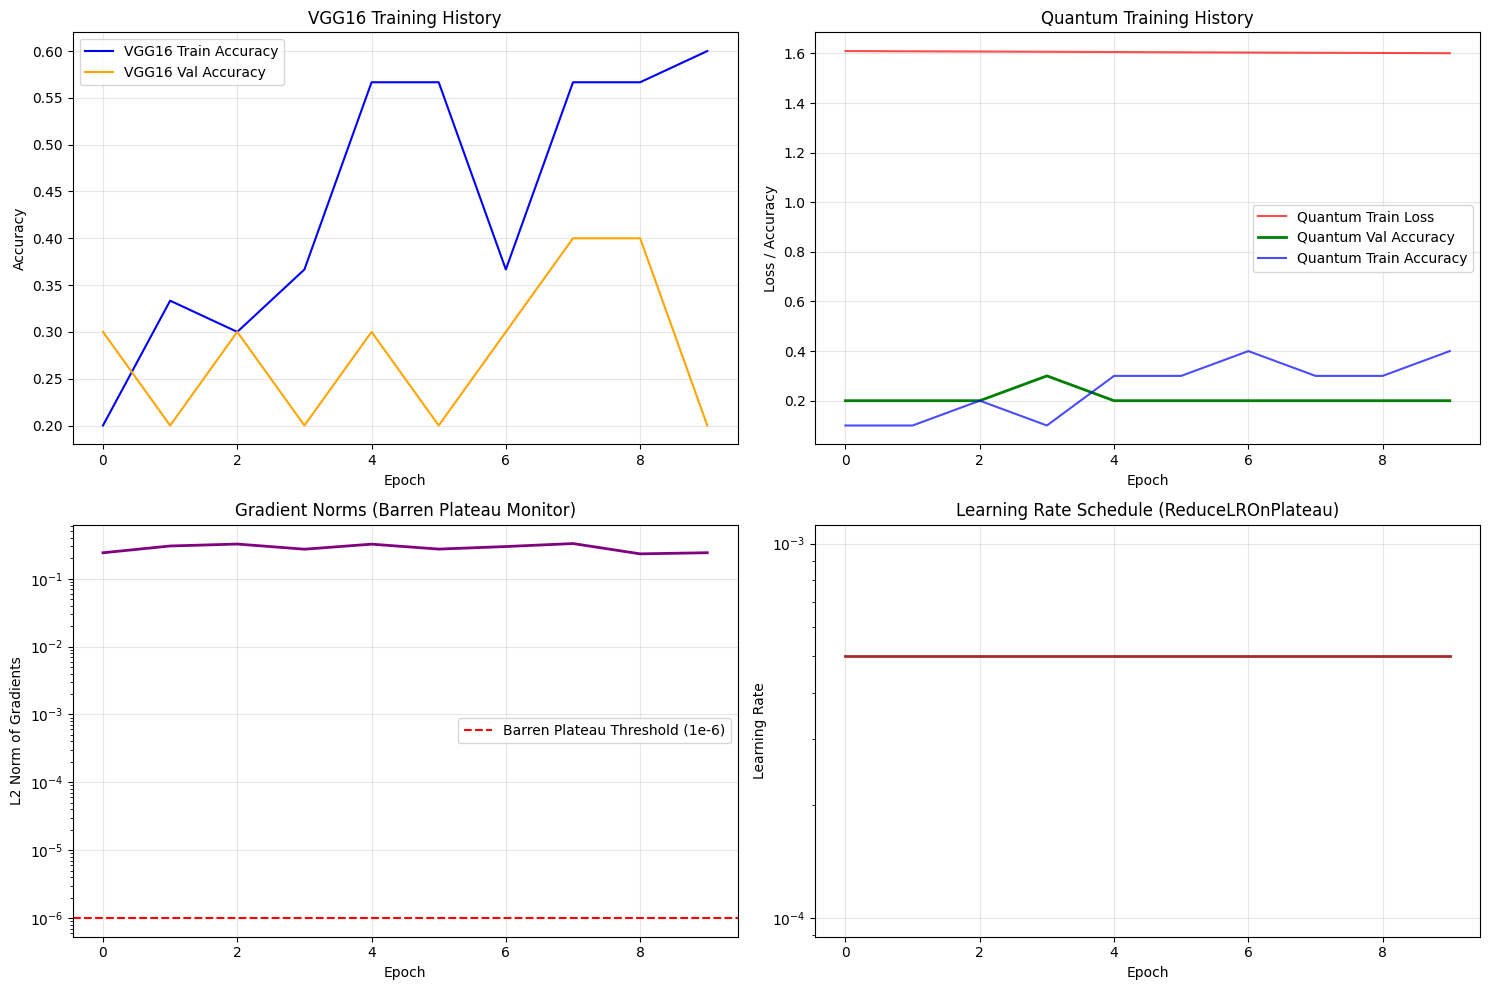

In [11]:
# ============================================================
# CELL 9: Training History Visualization
# ============================================================
print("\n Displaying Training History...")

fig = plt.figure(figsize=(15, 10))

ax1 = plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='VGG16 Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='VGG16 Val Accuracy', color='orange')
plt.title('VGG16 Training History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 2, 2)
plt.plot(train_losses, label='Quantum Train Loss', color='red', alpha=0.7)
plt.plot(val_accs, label='Quantum Val Accuracy', color='green', linewidth=2)
plt.plot(train_accs, label='Quantum Train Accuracy', color='blue', alpha=0.7)
plt.title('Quantum Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss / Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

ax3 = plt.subplot(2, 2, 3)
plt.plot(gradient_norms_history, color='purple', linewidth=2)
plt.axhline(y=1e-6, color='r', linestyle='--', label='Barren Plateau Threshold (1e-6)')
plt.title('Gradient Norms (Barren Plateau Monitor)')
plt.xlabel('Epoch')
plt.ylabel('L2 Norm of Gradients')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

ax4 = plt.subplot(2, 2, 4)
plt.plot(learning_rates, color='brown', linewidth=2)
plt.title('Learning Rate Schedule (ReduceLROnPlateau)')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 Generating Confusion Matrix...


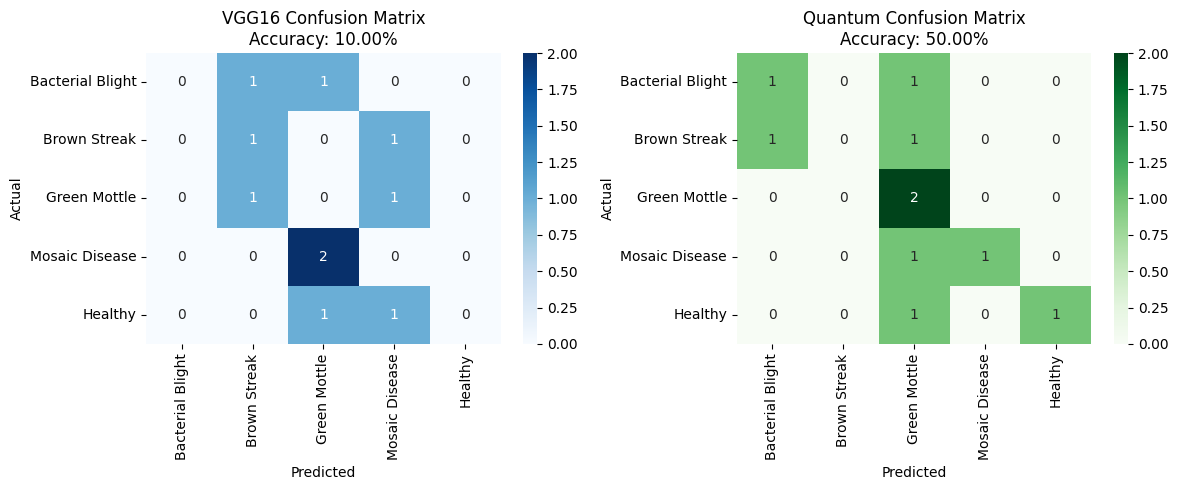

In [12]:

# CELL 10: Confusion Matrix

print("\n Generating Confusion Matrix...")

vgg16_preds = np.argmax(vgg16_model.predict(X_test, verbose=0), axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm_vgg16 = confusion_matrix(y_test, vgg16_preds)
sns.heatmap(cm_vgg16, annot=True, fmt='d', cmap='Blues', xticklabels=DISEASE_CLASSES.values(),
            yticklabels=DISEASE_CLASSES.values(), ax=ax1)
ax1.set_title(f'VGG16 Confusion Matrix\nAccuracy: {vgg16_acc*100:.2f}%')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

cm_quantum = confusion_matrix(y_test, preds_test)
sns.heatmap(cm_quantum, annot=True, fmt='d', cmap='Greens', xticklabels=DISEASE_CLASSES.values(),
            yticklabels=DISEASE_CLASSES.values(), ax=ax2)
ax2.set_title(f'Quantum Confusion Matrix\nAccuracy: {quantum_acc*100:.2f}%')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()


 HYBRID QUANTUM-CLASSICAL MODEL SUMMARY
 Dataset: Cassava Leaf Disease Classification
 Total Images: 50
 Classes: 5 disease types
 Architecture: VGG16 + Quantum Circuit
 VGG16 Parameters: 14,731,269
  Quantum Circuit: 2 qubits, 2 layers
 VGG16 Test Accuracy: 10.00%
 Quantum Test Accuracy: 50.00%

 Setup complete! You can now:
   1. View sample images from each class
   2. See training history plots
   3. View confusion matrices
   4. Use predict_image('path_to_image.jpg') for inference

 Example usage:
   pred_class, probs = predict_image('your_image.jpg')

🧪 Testing prediction function...
📸 Testing with: Cassava___bacterial_blight/478757157.jpg


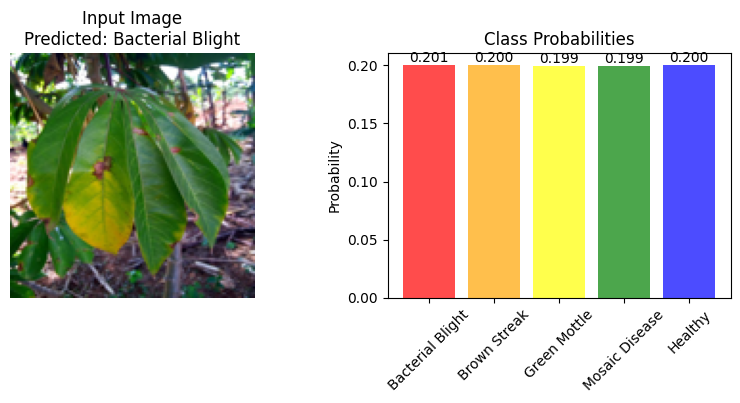


 Prediction: Bacterial Blight
 Confidence: 20.06%

 All probabilities:
   Bacterial Blight    : 20.06%
   Brown Streak        : 20.02%
   Green Mottle        : 19.95%
   Mosaic Disease      : 19.93%
   Healthy             : 20.05%

 COMPLETE CODE READY!


In [13]:

# CELL 11: Summary

print("\n" + "="*70)
print(" HYBRID QUANTUM-CLASSICAL MODEL SUMMARY")
print("="*70)
print(f" Dataset: Cassava Leaf Disease Classification")
print(f" Total Images: {len(images)}")
print(f" Classes: 5 disease types")
print(f" Architecture: VGG16 + Quantum Circuit")
print(f" VGG16 Parameters: {vgg16_model.count_params():,}")
print(f"  Quantum Circuit: {N_QUBITS} qubits, {QUANTUM_LAYERS} layers")
print(f" VGG16 Test Accuracy: {vgg16_acc*100:.2f}%")
print(f" Quantum Test Accuracy: {quantum_acc*100:.2f}%")
print("="*70)

print("\n Setup complete! You can now:")
print("   1. View sample images from each class")
print("   2. See training history plots")
print("   3. View confusion matrices")
print("   4. Use predict_image('path_to_image.jpg') for inference")
print("\n Example usage:")
print("   pred_class, probs = predict_image('your_image.jpg')")

print("\n🧪 Testing prediction function...")
data_folder = os.path.join(DATASET_PATH, 'data')
test_image_found = False

for folder_name in FOLDER_MAP.keys():
    folder_path = os.path.join(data_folder, folder_name)
    if os.path.exists(folder_path):
        image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if image_files:
            test_image_path = os.path.join(folder_path, image_files[0])
            print(f"📸 Testing with: {os.path.basename(folder_path)}/{image_files[0]}")
            try:
                predict_image(test_image_path)
                test_image_found = True
                break
            except Exception as e:
                print(f"     Test failed: {e}")
                continue

if not test_image_found:
    print("   ℹ  No test image found for demonstration")

print("\n COMPLETE CODE READY!")

In [14]:
# ============================================================
# CELL 12: Interactive Prediction Widget (FAIL-SAFE VERSION)
# ============================================================
print("---")
print(" INTERACTIVE IMAGE PREDICTOR (Fail-Safe Reset)")
print("---")

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import tempfile

    def create_uploader_widget():
        uploader = widgets.FileUpload(
            accept='.jpg,.jpeg,.png',
            multiple=False,
            description='Choose Cassava Leaf Image',
            button_style='info'
        )
        uploader.observe(on_upload_change, names='value')
        return uploader

    output_area = widgets.Output()

    def on_upload_change(change):
        uploader = change.owner

        with output_area:
            clear_output(wait=True)

            if uploader.value:
                uploaded_file_name = list(uploader.value.keys())[0]
                content = uploader.value[uploaded_file_name]['content']

                print(f"Uploaded file: *{uploaded_file_name}*")

                temp_path = None
                try:
                    with tempfile.NamedTemporaryFile(suffix=os.path.splitext(uploaded_file_name)[1], delete=False) as tmp:
                        tmp.write(content)
                        temp_path = tmp.name

                    print("\n Running hybrid quantum-classical prediction...")
                    predict_image(temp_path)

                except Exception as e:
                    print(f"\n *ERROR during prediction:*")
                    print(f"Please ensure the file is a valid image. Details: {e}")
                finally:
                    if temp_path and os.path.exists(temp_path):
                        os.remove(temp_path)

                print("\n-----------------------------------------------------------")
                print("Ready for next upload:")
                new_uploader = create_uploader_widget()
                display(new_uploader)

    print("Please upload a Cassava leaf image to get a disease prediction:")
    initial_uploader = create_uploader_widget()
    display(initial_uploader, output_area)

except ImportError:
    print("ℹ  Interactive widget not available (requires Jupyter environment)")
    print("   Use predict_image('path_to_image.jpg') function instead")

---
 INTERACTIVE IMAGE PREDICTOR (Fail-Safe Reset)
---
Please upload a Cassava leaf image to get a disease prediction:


FileUpload(value={}, accept='.jpg,.jpeg,.png', button_style='info', description='Choose Cassava Leaf Image')

Output()